<a href="https://colab.research.google.com/github/EmilianoCastelan/Procesos-Estocasticos/blob/main/Descomp_Canonica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

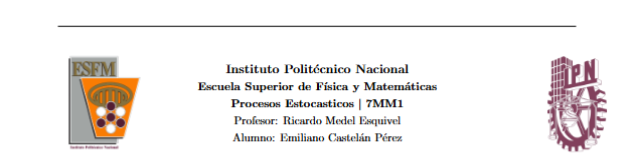

Se tiene la matriz de transición:

$
P=
\begin{pmatrix}
\frac14&0&0&0&0&0&\frac34\\
\frac18&\frac18&\frac14&0&\frac14&\frac18&\frac18\\
0&0&\frac25&\frac15&\frac25&0&0\\
0&0&\frac12&\frac12&0&0&0\\
0&0&0&\frac12&\frac12&0&0\\
0&\frac15&0&\frac15&\frac15&\frac15&\frac15\\
\frac45&0&0&0&0&0&\frac15
\end{pmatrix}
$

con estados:

$
S=\{a,b,c,d,e,f,g\}
$

## Paso 1: Identificar clases de comunicación

Observando las transiciones:


Los estados $a$ y $g$ se comunican entre sí:

$
a \leftrightarrow g
$

y no tienen transiciones hacia otros estados.

Por lo tanto:

$
\{a,g\}
$

es una clase cerrada recurrente.

Los estados $c,d,e$ también se comunican entre sí:

$
c \leftrightarrow d \leftrightarrow e
$

y tampoco salen hacia otros estados.

Entonces:

$
\{c,d,e\}
$

es otra clase cerrada recurrente.

Los estados $b$ y $f$ pueden llegar a otras clases,
pero no es posible regresar a ellos desde las clases cerradas.

Por tanto:

$
\{b,f\}
$

son estados transitorios.



## Paso 2: Reordenar los estados

Para obtener la forma canónica, colocamos:

 Primero los estados transitorios.

 Después las clases recurrentes.

$⟹$ Usaremos el orden:

$
(b,f,c,d,e,a,g)
$

## Paso 3: Reordenar filas y columnas

Tomamos las filas y columnas de $P$ en el nuevo orden:

$
(b,f,c,d,e,a,g)
$

**Fila correspondiente a $b$**

La fila original de $b$ es:

$
\left(
\frac18,\frac18,\frac14,0,\frac14,\frac18,\frac18
\right)
$

Reordenando columnas como:

$
(b,f,c,d,e,a,g)
$

obtenemos:

$
\left(
\frac18,\frac18,\frac14,0,\frac14,\frac18,\frac18
\right)
$

**Fila correspondiente a $f$**

Fila original:

$
\left(
0,\frac15,0,\frac15,\frac15,\frac15,\frac15
\right)
$

Reordenando:

$
\left(
\frac15,\frac15,0,\frac15,\frac15,0,\frac15
\right)
$

**Fila correspondiente a $c$**

Fila original:

$
\left(
0,0,\frac25,\frac15,\frac25,0,0
\right)
$

Reordenando:

$
\left(
0,0,\frac25,\frac15,\frac25,0,0
\right)
$

**Fila correspondiente a $d$**

Fila original:

$
\left(
0,0,\frac12,\frac12,0,0,0
\right)
$

Reordenando:

$
\left(
0,0,\frac12,\frac12,0,0,0
\right)
$

**Fila correspondiente a $e$**

Fila original:

$
\left(
0,0,0,\frac12,\frac12,0,0
\right)
$

Reordenando:

$
\left(
0,0,0,\frac12,\frac12,0,0
\right)
$

**Fila correspondiente a $a$**

Fila original:

$
\left(
\frac14,0,0,0,0,0,\frac34
\right)
$

Reordenando:

$
\left(
0,0,0,0,0,\frac14,\frac34
\right)
$

**Fila correspondiente a $g$**

Fila original:

$
\left(
\frac45,0,0,0,0,0,\frac15
\right)
$

Reordenando:

$
\left(
0,0,0,0,0,\frac45,\frac15
\right)
$

## Paso 4: Matriz canónica

Finalmente:

$
P_c=
\begin{pmatrix}
\frac18 & \frac18 & \frac14 & 0 & \frac14 & \frac18 & \frac18\\
\frac15 & \frac15 & 0 & \frac15 & \frac15 & 0 & \frac15\\
0 & 0 & \frac25 & \frac15 & \frac25 & 0 & 0\\
0 & 0 & \frac12 & \frac12 & 0 & 0 & 0\\
0 & 0 & 0 & \frac12 & \frac12 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & \frac14 & \frac34\\
0 & 0 & 0 & 0 & 0 & \frac45 & \frac15
\end{pmatrix}
$

La matriz quedó en forma canónica:

$
P_c=
\begin{pmatrix}
Q & R\\
0 & J
\end{pmatrix}
$

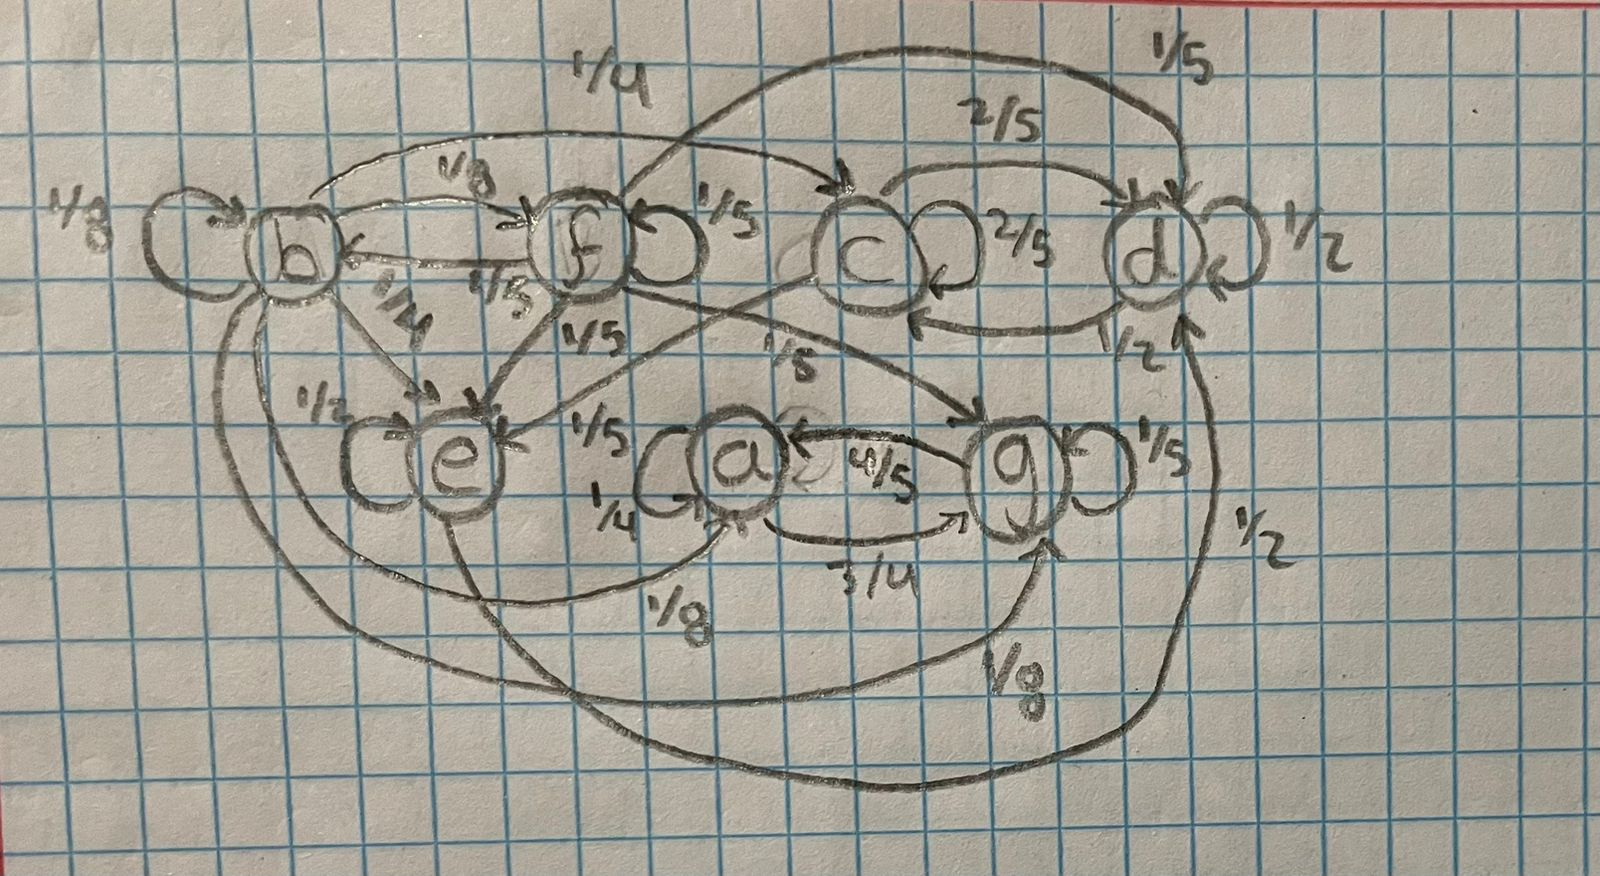

#Ahora, realizare el codigo para convertir la matriz en su forma canónica

In [3]:
import numpy as np
from collections import defaultdict

In [2]:
# Matriz original
P = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4],
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],
    [0,   0,   2/5, 1/5, 2/5, 0,   0],
    [0,   0,   1/2, 1/2, 0,   0,   0],
    [0,   0,   0,   1/2, 1/2, 0,   0],
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],
    [4/5, 0,   0,   0,   0,   0,   1/5]
])

In [9]:
def alcanzables(P, inicio):

    visitados = []
    pila = [inicio]

    while len(pila) > 0:

        x = pila.pop()

        if x not in visitados:

            visitados.append(x)

            for j in range(len(P)):

                if P[x][j] > 0:

                    if j not in visitados:
                        pila.append(j)

    return visitados


def se_comunican(P, i, j):

    a = alcanzables(P, i)
    b = alcanzables(P, j)

    if j in a and i in b:
        return True

    return False


def forma_canonica(P, estados):

    n = len(P)

    clases = []
    usados = []

    # buscar clases
    for i in range(n):

        if i not in usados:

            clase = []

            for j in range(n):

                if se_comunican(P, i, j):
                    clase.append(j)

            clases.append(clase)

            for x in clase:
                usados.append(x)

    cerradas = []
    transitorios = []

    # detectar cerradas
    for clase in clases:

        cerrada = True

        for i in clase:

            for j in range(n):

                if P[i][j] > 0 and j not in clase:
                    cerrada = False

        if cerrada:
            cerradas.append(clase)

        else:

            for x in clase:

                if x not in transitorios:
                    transitorios.append(x)

    # ordenar clases cerradas por tamaño
    cerradas.sort(key=len, reverse=True)

    # nuevo orden
    nuevo_orden = []

    for x in transitorios:
        nuevo_orden.append(x)

    for clase in cerradas:

        for x in clase:
            nuevo_orden.append(x)

    # construir nueva matriz
    nueva = np.zeros((n, n))

    for i in range(n):

        for j in range(n):

            nueva[i][j] = P[nuevo_orden[i]][nuevo_orden[j]]

    nombres = []

    for i in nuevo_orden:
        nombres.append(estados[i])

    return nombres, nueva

In [11]:
estados = ['a','b','c','d','e','f','g']

orden, Pc = forma_canonica(P, estados)

print("Orden nuevo:")
print(orden)

print("\nMatriz canonica:\n")
print(Pc)

Orden nuevo:
['b', 'f', 'c', 'd', 'e', 'a', 'g']

Matriz canonica:

[[0.125 0.125 0.25  0.    0.25  0.125 0.125]
 [0.2   0.2   0.    0.2   0.2   0.    0.2  ]
 [0.    0.    0.4   0.2   0.4   0.    0.   ]
 [0.    0.    0.5   0.5   0.    0.    0.   ]
 [0.    0.    0.    0.5   0.5   0.    0.   ]
 [0.    0.    0.    0.    0.    0.25  0.75 ]
 [0.    0.    0.    0.    0.    0.8   0.2  ]]
